In [26]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [27]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [29]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

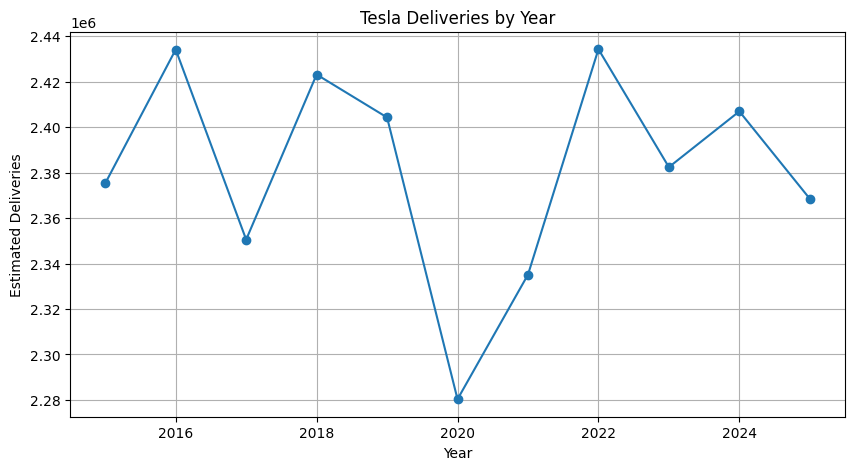

In [30]:
import matplotlib.pyplot as plt

yearly_sales = df.groupby("Year")["Estimated_Deliveries"].sum()

plt.figure(figsize=(10,5))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o')

plt.title("Tesla Deliveries by Year")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")

plt.grid(True)
plt.show()

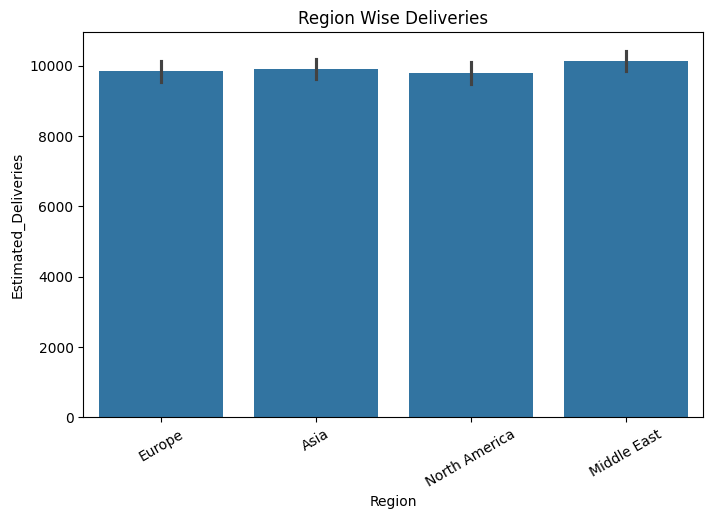

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Region",
    y="Estimated_Deliveries"
)

plt.title("Region Wise Deliveries")
plt.xticks(rotation=30)

plt.show()

In [32]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Convert text columns to numeric
df_ml = pd.get_dummies(df, columns=['Region','Model','Source_Type'])

X = df_ml.drop("Estimated_Deliveries", axis=1)
y = df_ml["Estimated_Deliveries"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2112, 20)
(528, 20)


In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}


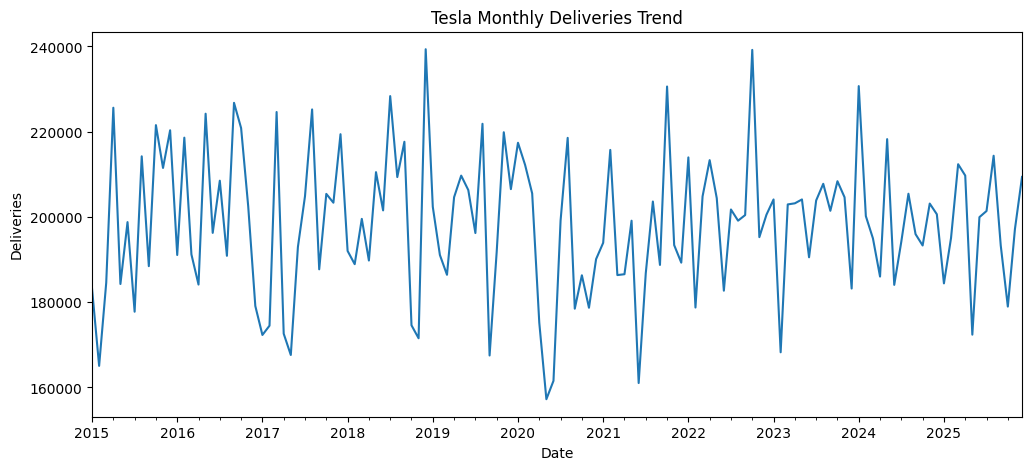

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str)
)

monthly_sales = df.groupby('Date')['Estimated_Deliveries'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot()

plt.title("Tesla Monthly Deliveries Trend")
plt.xlabel("Date")
plt.ylabel("Deliveries")

plt.show()

In [36]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


In [37]:
df.shape

(2640, 13)

In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3,
    n_jobs=-1
)

grid.fit(X, y)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10], 'n_estimators': [50, 100]})

In [39]:
grid.best_params_

{'max_depth': 10, 'n_estimators': 100}

In [40]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

print(df.shape)

(2640, 12)


In [41]:
df_ml = pd.get_dummies(df, columns=['Region','Model','Source_Type'])

X = df_ml.drop("Estimated_Deliveries", axis=1)
y = df_ml["Estimated_Deliveries"]

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2112, 20)
(528, 20)


In [43]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [44]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

pred = model.predict(X_test)

print("R2 Score :", r2_score(y_test, pred))
print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, pred)))

R2 Score : 0.9888238483185953
MAE : 322.8994507575758
RMSE : 408.160430701386


In [45]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

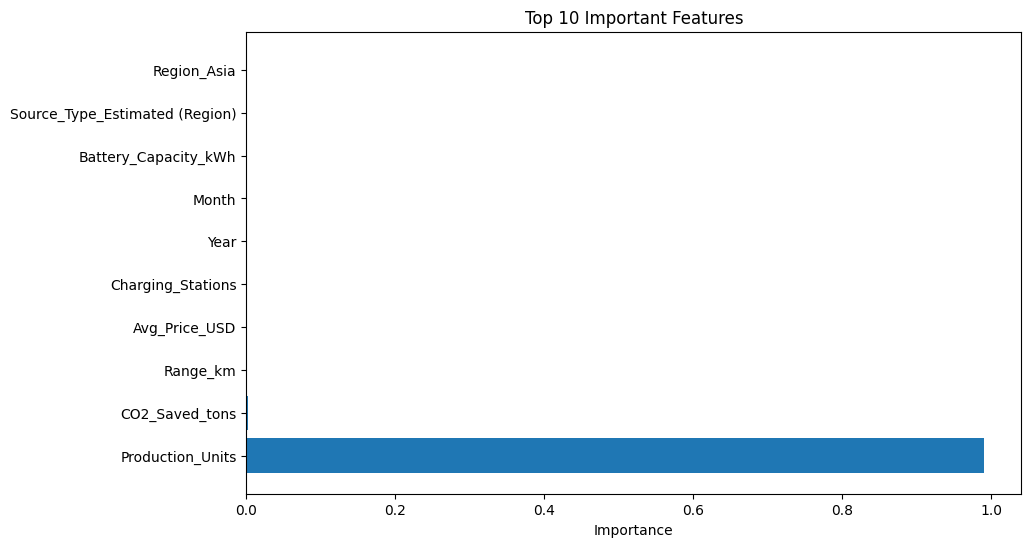

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'][:10],
    importance['Importance'][:10]
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")

plt.show()